<a href="https://colab.research.google.com/github/jasmin-05/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("credit_card_fraud_10k.csv")

df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df.shape

(10000, 10)

In [4]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [7]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


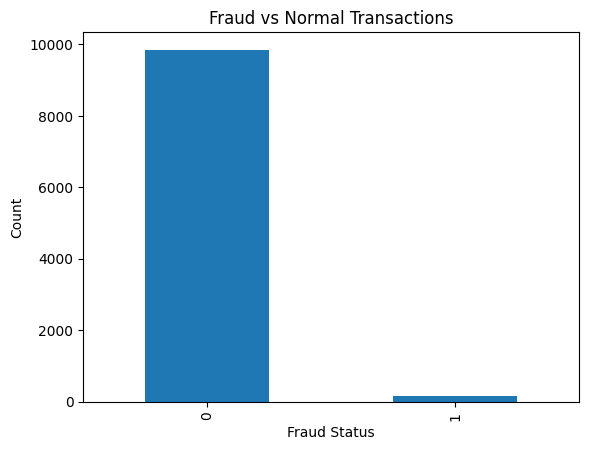

In [8]:
import matplotlib.pyplot as plt

df['is_fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

In [9]:
X = df.drop('is_fraud', axis=1)

y = df['is_fraud']

print(X.shape)
print(y.shape)

(10000, 9)
(10000,)


In [10]:
X = pd.get_dummies(X, columns=['merchant_category'], drop_first=True)

print(X.head())

   transaction_id  amount  transaction_hour  foreign_transaction  \
0               1   84.47                22                    0   
1               2  541.82                 3                    1   
2               3  237.01                17                    0   
3               4  164.33                 4                    0   
4               5   30.53                15                    0   

   location_mismatch  device_trust_score  velocity_last_24h  cardholder_age  \
0                  0                  66                  3              40   
1                  0                  87                  1              64   
2                  0                  49                  1              61   
3                  1                  72                  3              34   
4                  0                  79                  0              44   

   merchant_category_Electronics  merchant_category_Food  \
0                           True                   False

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 12)
(2000, 12)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9905


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       0.88      0.45      0.60        31

    accuracy                           0.99      2000
   macro avg       0.93      0.73      0.80      2000
weighted avg       0.99      0.99      0.99      2000



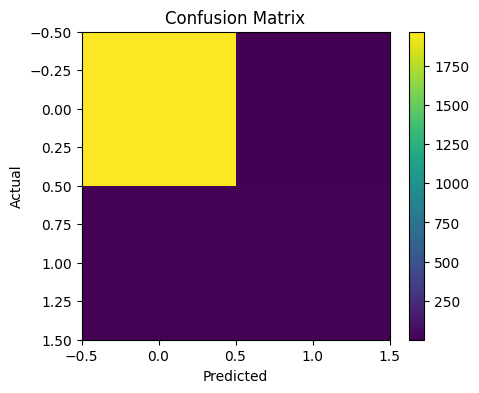

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print(prediction)              # normal transaction

[0]


In [20]:
fraud_samples = X_test[y_test == 1]

sample = fraud_samples.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[1]


In [21]:
print(y_test.value_counts())

is_fraud
0    1969
1      31
Name: count, dtype: int64
